In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import pickle

In [2]:
## Load dataset
data= pd.read_csv('Churn_Modelling.csv')
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
## Preprocess the data
## Drop Irrelevant columns
data= data.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)
data.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
# Encode categorical variables
label_encoder_gender=LabelEncoder()
data['Gender']=label_encoder_gender.fit_transform(data['Gender'])
data.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,0,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,0,41,1,83807.86,1,0,1,112542.58,0
2,502,France,0,42,8,159660.80,3,1,0,113931.57,1
3,699,France,0,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,0,43,2,125510.82,1,1,1,79084.10,0


In [5]:
# Onehot encode 'Geography' column
from sklearn.preprocessing import OneHotEncoder
one_hot_encoder_geo=OneHotEncoder()
geo_encoder=one_hot_encoder_geo.fit_transform(data[['Geography']])
geo_encoder

<10000x3 sparse matrix of type '<class 'numpy.float64'>'
	with 10000 stored elements in Compressed Sparse Row format>

In [6]:
geo_encoder.toarray()

array([[1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       ...,
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.]])

In [7]:
one_hot_encoder_geo.get_feature_names_out(['Geography'])

array(['Geography_France', 'Geography_Germany', 'Geography_Spain'],
      dtype=object)

In [8]:
geo_encoded_df=pd.DataFrame(geo_encoder.toarray(), columns=one_hot_encoder_geo.get_feature_names_out(['Geography']))
geo_encoded_df

,Geography_France,Geography_Germany,Geography_Spain
0,1.0,0.0,0.0
1,0.0,0.0,1.0
2,1.0,0.0,0.0
3,1.0,0.0,0.0
4,0.0,0.0,1.0
...,...,...,...
9995,1.0,0.0,0.0
9996,1.0,0.0,0.0
9997,1.0,0.0,0.0
9998,0.0,1.0,0.0


In [9]:
# Combine columns
data=pd.concat([data.drop('Geography', axis=1), geo_encoded_df], axis=1)
data.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,1.0,0.0,0.0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0.0,0.0,1.0
2,502,0,42,8,159660.80,3,1,0,113931.57,1,1.0,0.0,0.0
3,699,0,39,1,0.00,2,0,0,93826.63,0,1.0,0.0,0.0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0.0,0.0,1.0


In [10]:
# Save the encoders and scalar
with open('label_encoder_gender.pkl','wb')as file:
    pickle.dump(label_encoder_gender,file)

with open('one_hot_encoder_geo.pkl','wb') as file:
    pickle.dump(one_hot_encoder_geo, file)


In [11]:
data.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,1.0,0.0,0.0
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0.0,0.0,1.0
2,502,0,42,8,159660.80,3,1,0,113931.57,1,1.0,0.0,0.0
3,699,0,39,1,0.00,2,0,0,93826.63,0,1.0,0.0,0.0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0.0,0.0,1.0


In [12]:
# Divide the dataset into training and testing sets
X=data.drop('Exited', axis=1)
y=data['Exited']

# Split data into traing and testing sets
X_train, X_test, y_train, y_test= train_test_split(X,y, test_size=0.2, random_state=42)

# Scale these features
scaler = StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [13]:
with open('scaler.pkl', 'wb') as file:
    pickle.dump(scaler, file)

ANN Implementation

In [14]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping, TensorBoard
import datetime


In [15]:
(X_train.shape[1],)

(12,)

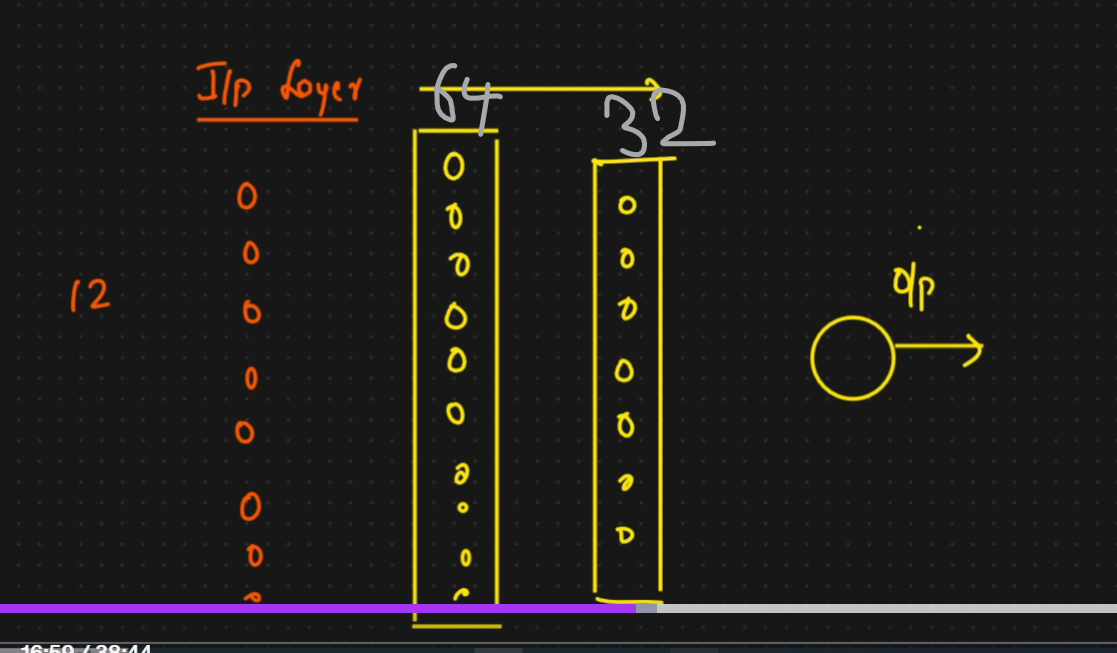

In [16]:
# Build our ANN model
model=Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),                  ## HL1 connected with Input Layer
    Dense(32,activation='relu'),                                                              ## HL2 connected with HL1
    Dense(1,activation='sigmoid')                                                   # Output layer connected with HL2
    
])  



c:\Users\HP\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,945 (11.50 KB)

 Trainable params: 2,945 (11.50 KB)

 Non-trainable params: 0 (0.00 B)

### To do Backward Propagation, we need to compile the model first. We need to specify the optimizer, loss function and metrics for evaluation.


In [18]:
opt=tf.keras.optimizers.Adam(learning_rate=0.01)
loss=tf.keras.losses.BinaryCrossentropy()
loss

<LossFunctionWrapper(<function binary_crossentropy at 0x00000160D9C88040>, kwargs={'from_logits': False, 'label_smoothing': 0.0, 'axis': -1})>

In [19]:
# To do Backward Propagation, we need to compile the model first. We need to specify the optimizer, loss function and metrics for evaluation.
# Compile the model
model.compile(optimizer='adam',loss='binary_crossentropy', metrics=['accuracy'])

In [20]:
# Set up the Tensorboard
from tensorflow.keras.callbacks import EarlyStopping, TensorBoard
log_dir="logs/fit/" +datetime.datetime.now().strftime("%Y%m%d=%H%M%S")

tensorflow_callback=TensorBoard(log_dir=log_dir, histogram_freq=1)

In [21]:
# Set up Early Stopping
early_stopping_callback= EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [22]:
#Train the model
history=model.fit(
    X_train, y_train, validation_data=(X_test, y_test), epochs=100,
    callbacks=[tensorflow_callback, early_stopping_callback]
)

Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7969 - loss: 0.4591 - val_accuracy: 0.8340 - val_loss: 0.3931
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8428 - loss: 0.3862 - val_accuracy: 0.8535 - val_loss: 0.3611
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8562 - loss: 0.3562 - val_accuracy: 0.8570 - val_loss: 0.3481
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8581 - loss: 0.3455 - val_accuracy: 0.8575 - val_loss: 0.3477
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8612 - loss: 0.3400 - val_accuracy: 0.8585 - val_loss: 0.3436
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8611 - loss: 0.3360 - val_accuracy: 0.8635 - val_loss: 0.3384
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8600 - loss: 0.3327 - val_accuracy: 0.8635 - val_loss: 0.3377
Epoch 8/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8645 - loss: 0.3299 - val_accu

In [23]:
model.save("my_model.h5")

In [ ]:
# Load Tensorboard Extension
%load_ext tensorboard

In [30]:
import os
print(os.getcwd())
print(os.path.exists("logs/fit"))
print(os.listdir("logs/fit"))

c:\Projects\KrishNaik\ANN
True
['20260512=165122', '20260512=181232']


In [32]:
%tensorboard --logdir logs/fit

Reusing TensorBoard on port 6006 (pid 3672), started 0:01:59 ago. (Use '!kill 3672' to kill it.)

In [ ]:
# Evaluate on the test set:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test accuracy:", accuracy)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8590 - loss: 0.3335
Test accuracy: 0.859000027179718


In [29]:
# Inspect the training history:
# 
print("Train accuracy:", history.history['accuracy'][-1])
print("Validation accuracy:", history.history['val_accuracy'][-1])

Train accuracy: 0.8705000281333923
Validation accuracy: 0.8619999885559082


In [33]:
%tensorboard --logdir logs/fit

Reusing TensorBoard on port 6006 (pid 3672), started 0:02:29 ago. (Use '!kill 3672' to kill it.)